# Script 04: VALIS Registration of IMC GBM Samples to H&E

Register IMC GBM cores (from adjacent TMA section) to the H&E reference used by Xenium/MSI.

**Scope**: 20 GBM ROIs segmented with QuPath StarDist.

**Strategy**: Per-core registration of IMC DNA channel -> H&E crop, following the pattern from
script01a/01b (Xenium DAPI -> H&E).

**Parts**:
- Part A: Prepare images (extract IMC DNA channel, crop H&E per core)
- Part B: Run VALIS registration per core, warp coordinates, update AnnData files

**Conda env**: `valis_registration`

In [1]:
from valis import registration
import tifffile as tiff
from matplotlib import pyplot as plt
from PIL import Image
import numpy as np
import os
import pandas as pd
import anndata as ad
import cv2
import pickle

c:\Apps\miniconda3\envs\maitra_spatial\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded LightGlue model
Loaded LightGlue model


In [2]:
project_root = 'T:/Analysis/116_MDACC_Chiba/'

# IMC OME-TIFFs
imc_ometiff_dir = os.path.join(project_root, 'Astraea_Clients_GoogleDrive/Chiba_Data/IMC_First_set/Chiba_ome-tiff/')

# H&E reference (registered, from Xenium pipeline)
he_registered_path = os.path.join(
    project_root, 'chiba/out_feb2025_xenium/',
    'script01b_registration_out_xeDapi_he__high_res_he_/registered/he_rotated_3dim.ome.tiff'
)

# Existing registrar pickle (for reference transforms)
registrar_pickle_path = os.path.join(
    project_root, 'chiba/out_feb2025_xenium/',
    'script01b_registration_out_xeDapi_he__high_res_he_/results/reg01_dapi_he/data/reg01_dapi_he_registrar.pickle'
)

# IMC AnnData files (from script03)
adata_dir = os.path.join(project_root, 'chiba/out_feb2025__protein_analysis_imc_orig/script01_imc_adatas/')

# Output directories
out_root = os.path.join(project_root, 'chiba/out_feb2025_imc_registration/')
images_out_dir = os.path.join(out_root, 'script04_imc_images_for_valis/')
reg_out_dir = os.path.join(out_root, 'script04_registration_out/')

os.makedirs(images_out_dir, exist_ok=True)
os.makedirs(reg_out_dir, exist_ok=True)

print(f'IMC OME-TIFFs: {imc_ometiff_dir}')
print(f'H&E reference: {he_registered_path}')
print(f'AnnData dir: {adata_dir}')
print(f'Output: {out_root}')

IMC OME-TIFFs: T:/Analysis/116_MDACC_Chiba/Astraea_Clients_GoogleDrive/Chiba_Data/IMC_First_set/Chiba_ome-tiff/
H&E reference: T:/Analysis/116_MDACC_Chiba/chiba/out_feb2025_xenium/script01b_registration_out_xeDapi_he__high_res_he_/registered/he_rotated_3dim.ome.tiff
AnnData dir: T:/Analysis/116_MDACC_Chiba/chiba/out_feb2025__protein_analysis_imc_orig/script01_imc_adatas/
Output: T:/Analysis/116_MDACC_Chiba/chiba/out_feb2025_imc_registration/


In [3]:
# 20 GBM ROIs segmented with QuPath StarDist
# (Mesmer segmentation failed for GBM samples due to Channel 0/DAPI being flat background)
gbm_rois = [
    'ROI1_GBM5-Core', 'ROI2_GBM10-Core', 'ROI5_GBM5-Edge', 'ROI6_GBM10-Edge',
    'ROI9_GBM4-Core', 'ROI10_GBM9-Core', 'ROI13_GBM4-Edge', 'ROI14_GBM9-Edge',
    'ROI17_GBM3-Core', 'ROI18_GBM8-Core', 'ROI21_GBM3-Edge', 'ROI22_GBM8-Edge',
    'ROI25_GBM2-Core', 'ROI26_GBM7-Core', 'ROI29_GBM2-Edge', 'ROI30_GBM7-Edge',
    'ROI33_GBM1-Core', 'ROI34_GBM6-Core', 'ROI37_GBM1-Edge', 'ROI38_GBM6-Edge',
]

# Map ROI sample names to their OME-TIFF filenames
imc_files = [f for f in os.listdir(imc_ometiff_dir) if f.endswith('.ome.tiff')]

roi_to_ometiff = {}
for roi_name in gbm_rois:
    matching = [f for f in imc_files if f.startswith(roi_name + '.')]
    if matching:
        roi_to_ometiff[roi_name] = matching[0]
    else:
        print(f'WARNING: No OME-TIFF found for {roi_name}')

print(f'Matched {len(roi_to_ometiff)}/{len(gbm_rois)} GBM ROIs to OME-TIFFs')
for k, v in sorted(roi_to_ometiff.items()):
    print(f'  {k} -> {v}')

Matched 20/20 GBM ROIs to OME-TIFFs
  ROI10_GBM9-Core -> ROI10_GBM9-Core.ome.tiff
  ROI13_GBM4-Edge -> ROI13_GBM4-Edge.ome.tiff
  ROI14_GBM9-Edge -> ROI14_GBM9-Edge.ome.tiff
  ROI17_GBM3-Core -> ROI17_GBM3-Core.ome.tiff
  ROI18_GBM8-Core -> ROI18_GBM8-Core.ome.tiff
  ROI1_GBM5-Core -> ROI1_GBM5-Core.ome.tiff
  ROI21_GBM3-Edge -> ROI21_GBM3-Edge.ome.tiff
  ROI22_GBM8-Edge -> ROI22_GBM8-Edge.ome.tiff
  ROI25_GBM2-Core -> ROI25_GBM2-Core.ome.tiff
  ROI26_GBM7-Core -> ROI26_GBM7-Core.ome.tiff
  ROI29_GBM2-Edge -> ROI29_GBM2-Edge.ome.tiff
  ROI2_GBM10-Core -> ROI2_GBM10-Core.ome.tiff
  ROI30_GBM7-Edge -> ROI30_GBM7-Edge.ome.tiff
  ROI33_GBM1-Core -> ROI33_GBM1-Core.ome.tiff
  ROI34_GBM6-Core -> ROI34_GBM6-Core.ome.tiff
  ROI37_GBM1-Edge -> ROI37_GBM1-Edge.ome.tiff
  ROI38_GBM6-Edge -> ROI38_GBM6-Edge.ome.tiff
  ROI5_GBM5-Edge -> ROI5_GBM5-Edge.ome.tiff
  ROI6_GBM10-Edge -> ROI6_GBM10-Edge.ome.tiff
  ROI9_GBM4-Core -> ROI9_GBM4-Core.ome.tiff


---
## Part A: Prepare Images for VALIS

1. Extract DNA channel (index 30) from each IMC OME-TIFF, normalize to uint8
2. Load the registered H&E and prepare per-core crops

For per-core H&E crops, we need to define approximate bounding boxes for each TMA core
in the H&E image. These will be determined interactively or from existing metadata.

In [4]:
DNA_CHANNEL_IDX = 30  # DNA/nuclear channel in OME-TIFF (matches DAPI)

dna_images_dir = os.path.join(images_out_dir, 'imc_dna_channel/')
os.makedirs(dna_images_dir, exist_ok=True)

for roi_name, ometiff_name in sorted(roi_to_ometiff.items()):
    ometiff_path = os.path.join(imc_ometiff_dir, ometiff_name)
    
    # Read only the DNA channel
    img = tiff.imread(ometiff_path)
    dna_channel = img[DNA_CHANNEL_IDX, :, :]
    
    # Normalize to uint8 with quantile clipping (same approach as script01)
    upper_q = np.quantile(dna_channel, 0.999)
    clipped = np.clip(dna_channel, 0, upper_q)
    dna_uint8 = cv2.normalize(clipped, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    
    # Add padding (50px each side, matches MSI prep convention from script01a)
    dna_padded = np.pad(dna_uint8, 50, mode='constant', constant_values=0)
    
    # Save as TIFF
    out_path = os.path.join(dna_images_dir, f'{roi_name}_dna.tiff')
    tiff.imwrite(out_path, dna_padded)
    
    print(f'  {roi_name}: {img.shape} -> DNA channel {dna_channel.shape} -> padded {dna_padded.shape}')

print(f'\nSaved {len(roi_to_ometiff)} DNA channel images to {dna_images_dir}')

  ROI10_GBM9-Core: (36, 1010, 983) -> DNA channel (1010, 983) -> padded (1110, 1083)
  ROI13_GBM4-Edge: (36, 1032, 823) -> DNA channel (1032, 823) -> padded (1132, 923)
  ROI14_GBM9-Edge: (36, 1000, 1000) -> DNA channel (1000, 1000) -> padded (1100, 1100)
  ROI17_GBM3-Core: (36, 967, 1065) -> DNA channel (967, 1065) -> padded (1067, 1165)
  ROI18_GBM8-Core: (36, 1032, 1037) -> DNA channel (1032, 1037) -> padded (1132, 1137)
  ROI1_GBM5-Core: (36, 922, 671) -> DNA channel (922, 671) -> padded (1022, 771)
  ROI21_GBM3-Edge: (36, 1086, 1019) -> DNA channel (1086, 1019) -> padded (1186, 1119)
  ROI22_GBM8-Edge: (36, 1000, 935) -> DNA channel (1000, 935) -> padded (1100, 1035)
  ROI25_GBM2-Core: (36, 1072, 1072) -> DNA channel (1072, 1072) -> padded (1172, 1172)
  ROI26_GBM7-Core: (36, 1247, 1462) -> DNA channel (1247, 1462) -> padded (1347, 1562)
  ROI29_GBM2-Edge: (36, 1034, 1069) -> DNA channel (1034, 1069) -> padded (1134, 1169)
  ROI2_GBM10-Core: (36, 1037, 1021) -> DNA channel (1037, 

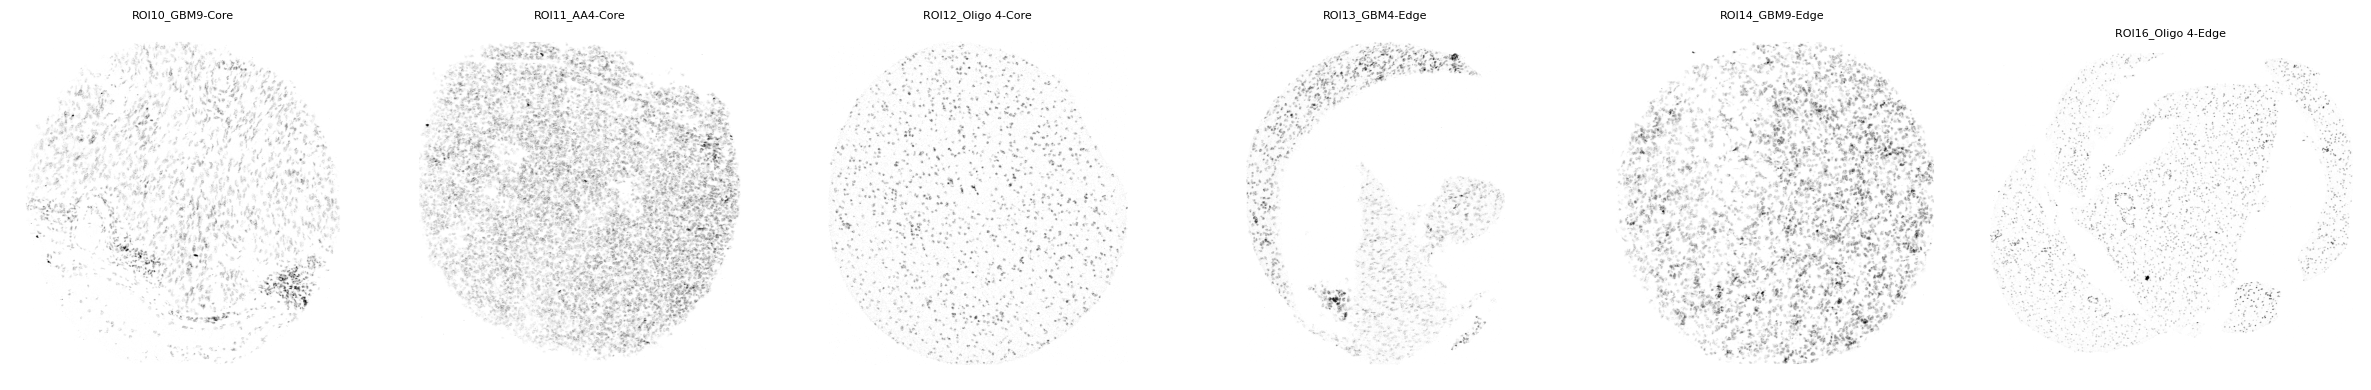

In [5]:
# Quick visualization of a few DNA channel images
dna_files = sorted([f for f in os.listdir(dna_images_dir) if f.endswith('.tiff')])
n_show = min(6, len(dna_files))

fig, axes = plt.subplots(1, n_show, figsize=(n_show * 4, 4))
if n_show == 1:
    axes = [axes]
for i in range(n_show):
    img = tiff.imread(os.path.join(dna_images_dir, dna_files[i]))
    axes[i].imshow(img, cmap='gray_r')
    axes[i].set_title(dna_files[i].replace('_dna.tiff', ''), fontsize=8)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

### Load H&E and define per-core crop regions

The H&E image covers the full TMA. We need to crop it to individual core regions
for per-core registration with IMC.

**NOTE**: The crop coordinates below need to be determined empirically by examining
the H&E image. Adjust the `core_crops` dictionary as needed.

H&E image shape: (11500, 6000, 3), dtype: uint8


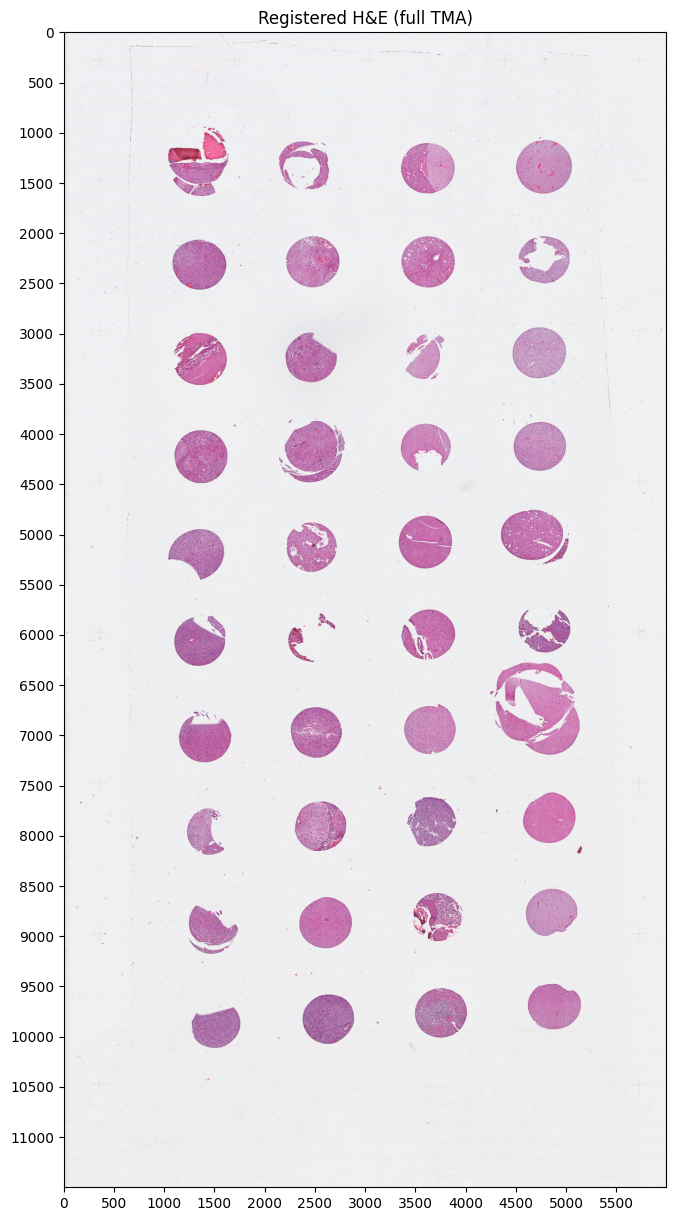

In [8]:
he_img = tiff.imread(he_registered_path)
print(f'H&E image shape: {he_img.shape}, dtype: {he_img.dtype}')

fig, ax = plt.subplots(1, 1, figsize=(10, 15))
ax.imshow(he_img)
ax.set_title('Registered H&E (full TMA)')
ax.axis('on')  # Keep axes on for coordinate reference
ax.set_xticks(np.arange(0, he_img.shape[1], 500))
ax.set_yticks(np.arange(0, he_img.shape[0], 500))
plt.show()

In [9]:
# H&E crop regions per GBM tissue core: {tissue_name: (row_start, row_end, col_start, col_end)}
# Derived from TMA grid trough coordinates in script04b_prepare_dapi_he_images_by_cores.ipynb
#
# TMA layout: 4 columns (x1-x4) x 10 rows (y1-y10)
# GBM cores are in columns x3 (GBM6-10) and x4 (GBM1-5)
#
# Column pixel ranges (on registered H&E 11500x6000):
#   x3: cols 2000-3200
#   x4: cols 900-2000
#
# Row pixel ranges (troughs_y1, starting from 750):
#   y1:  750-1900,  y2: 1900-2800, y3: 2800-3800, y4: 3800-4700, y5: 4700-5600
#   y6: 5600-6500,  y7: 6500-7400, y8: 7400-8400, y9: 8400-9300, y10: 9300-10750

# Extract tissue name from ROI name (e.g. 'ROI33_GBM1-Core' -> 'GBM1-Core')
def roi_to_tissue_name(roi_name):
    """Extract tissue name from ROI identifier."""
    parts = roi_name.split('_', 1)
    return parts[1] if len(parts) > 1 else roi_name

# Row boundaries
y_bounds = [750, 1900, 2800, 3800, 4700, 5600, 6500, 7400, 8400, 9300, 10750]

core_crops = {}

# x3 column (cols 2000-3200): GBM6-10, Edge/Core alternating per row
x3_samples = ['GBM6-Edge', 'GBM6-Core', 'GBM7-Edge', 'GBM7-Core', 'GBM8-Edge',
              'GBM8-Core', 'GBM9-Edge', 'GBM9-Core', 'GBM10-Edge', 'GBM10-Core']
for i, name in enumerate(x3_samples):
    core_crops[name] = (y_bounds[i], y_bounds[i+1], 2000, 3200)

# x4 column (cols 900-2000): GBM1-5, Edge/Core alternating per row
x4_samples = ['GBM1-Edge', 'GBM1-Core', 'GBM2-Edge', 'GBM2-Core', 'GBM3-Edge',
              'GBM3-Core', 'GBM4-Edge', 'GBM4-Core', 'GBM5-Edge', 'GBM5-Core']
for i, name in enumerate(x4_samples):
    core_crops[name] = (y_bounds[i], y_bounds[i+1], 900, 2000)

# Verify all GBM ROIs have crop definitions
for roi_name in gbm_rois:
    tissue = roi_to_tissue_name(roi_name)
    bounds = core_crops.get(tissue)
    if bounds is None:
        print(f'  MISSING crop for: {roi_name} (tissue: {tissue})')
    else:
        r0, r1, c0, c1 = bounds
        print(f'  OK: {roi_name} -> {tissue}  [{r0}:{r1}, {c0}:{c1}]  ({r1-r0}x{c1-c0} px)')

  OK: ROI1_GBM5-Core -> GBM5-Core  [9300:10750, 900:2000]  (1450x1100 px)
  OK: ROI2_GBM10-Core -> GBM10-Core  [9300:10750, 2000:3200]  (1450x1200 px)
  OK: ROI5_GBM5-Edge -> GBM5-Edge  [8400:9300, 900:2000]  (900x1100 px)
  OK: ROI6_GBM10-Edge -> GBM10-Edge  [8400:9300, 2000:3200]  (900x1200 px)
  OK: ROI9_GBM4-Core -> GBM4-Core  [7400:8400, 900:2000]  (1000x1100 px)
  OK: ROI10_GBM9-Core -> GBM9-Core  [7400:8400, 2000:3200]  (1000x1200 px)
  OK: ROI13_GBM4-Edge -> GBM4-Edge  [6500:7400, 900:2000]  (900x1100 px)
  OK: ROI14_GBM9-Edge -> GBM9-Edge  [6500:7400, 2000:3200]  (900x1200 px)
  OK: ROI17_GBM3-Core -> GBM3-Core  [5600:6500, 900:2000]  (900x1100 px)
  OK: ROI18_GBM8-Core -> GBM8-Core  [5600:6500, 2000:3200]  (900x1200 px)
  OK: ROI21_GBM3-Edge -> GBM3-Edge  [4700:5600, 900:2000]  (900x1100 px)
  OK: ROI22_GBM8-Edge -> GBM8-Edge  [4700:5600, 2000:3200]  (900x1200 px)
  OK: ROI25_GBM2-Core -> GBM2-Core  [3800:4700, 900:2000]  (900x1100 px)
  OK: ROI26_GBM7-Core -> GBM7-Core  [380

In [10]:
he_crops_dir = os.path.join(images_out_dir, 'he_core_crops/')
os.makedirs(he_crops_dir, exist_ok=True)

for tissue_name, (r0, r1, c0, c1) in core_crops.items():
    he_crop = he_img[r0:r1, c0:c1, :]
    out_path = os.path.join(he_crops_dir, f'he_{tissue_name}.tiff')
    tiff.imwrite(out_path, he_crop)
    print(f'  {tissue_name}: crop [{r0}:{r1}, {c0}:{c1}] -> shape {he_crop.shape}')

print(f'\nSaved {len(core_crops)} H&E crops to {he_crops_dir}')

  GBM6-Edge: crop [750:1900, 2000:3200] -> shape (1150, 1200, 3)
  GBM6-Core: crop [1900:2800, 2000:3200] -> shape (900, 1200, 3)
  GBM7-Edge: crop [2800:3800, 2000:3200] -> shape (1000, 1200, 3)
  GBM7-Core: crop [3800:4700, 2000:3200] -> shape (900, 1200, 3)
  GBM8-Edge: crop [4700:5600, 2000:3200] -> shape (900, 1200, 3)
  GBM8-Core: crop [5600:6500, 2000:3200] -> shape (900, 1200, 3)
  GBM9-Edge: crop [6500:7400, 2000:3200] -> shape (900, 1200, 3)
  GBM9-Core: crop [7400:8400, 2000:3200] -> shape (1000, 1200, 3)
  GBM10-Edge: crop [8400:9300, 2000:3200] -> shape (900, 1200, 3)
  GBM10-Core: crop [9300:10750, 2000:3200] -> shape (1450, 1200, 3)
  GBM1-Edge: crop [750:1900, 900:2000] -> shape (1150, 1100, 3)
  GBM1-Core: crop [1900:2800, 900:2000] -> shape (900, 1100, 3)
  GBM2-Edge: crop [2800:3800, 900:2000] -> shape (1000, 1100, 3)
  GBM2-Core: crop [3800:4700, 900:2000] -> shape (900, 1100, 3)
  GBM3-Edge: crop [4700:5600, 900:2000] -> shape (900, 1100, 3)
  GBM3-Core: crop [5600

---
## Part B: VALIS Registration Per Core

For each core:
1. Create a temp directory with the IMC DNA image + H&E crop
2. Run VALIS registration (H&E as reference)
3. Warp IMC cell centroids to H&E space
4. Save warped coordinates into AnnData `obsm['spatial_warped']`

In [11]:
import shutil

failed_rois = []
successful_rois = []

for roi_name in sorted(gbm_rois):
    tissue_name = roi_to_tissue_name(roi_name)
    
    if tissue_name not in core_crops:
        print(f'SKIP {roi_name}: no H&E crop defined for {tissue_name}')
        continue
    
    print(f'\n--- Registering {roi_name} ({tissue_name}) ---')
    
    # Paths
    imc_dna_path = os.path.join(dna_images_dir, f'{roi_name}_dna.tiff')
    he_crop_path = os.path.join(he_crops_dir, f'he_{tissue_name}.tiff')
    
    if not os.path.exists(imc_dna_path):
        print(f'  WARNING: IMC DNA image not found: {imc_dna_path}')
        failed_rois.append(roi_name)
        continue
    if not os.path.exists(he_crop_path):
        print(f'  WARNING: H&E crop not found: {he_crop_path}')
        failed_rois.append(roi_name)
        continue
    
    # Create temp slide source directory with both images
    slide_src = os.path.join(reg_out_dir, f'{roi_name}_slides')
    os.makedirs(slide_src, exist_ok=True)
    
    shutil.copy2(imc_dna_path, os.path.join(slide_src, f'{roi_name}_dna.tiff'))
    shutil.copy2(he_crop_path, os.path.join(slide_src, f'he_{tissue_name}.tiff'))
    
    # VALIS registration
    results_dir = os.path.join(reg_out_dir, f'{roi_name}_results')
    registered_dir = os.path.join(reg_out_dir, f'{roi_name}_registered')
    
    try:
        registrar = registration.Valis(
            slide_src,
            results_dir,
            check_for_reflections=True,
            reference_img_f=f'he_{tissue_name}.tiff',
            align_to_reference=True,
        )
        rigid_registrar, non_rigid_registrar, error_df = registrar.register()
        registrar.warp_and_save_slides(registered_dir, crop='reference')
        
        print(f'  Registration complete. Error summary:')
        print(error_df.to_string(index=False))
        
        successful_rois.append((roi_name, registrar))
        
    except Exception as e:
        print(f'  FAILED: {e}')
        failed_rois.append(roi_name)

print(f'\n\nRegistration complete: {len(successful_rois)} succeeded, {len(failed_rois)} failed')
if failed_rois:
    print(f'Failed: {failed_rois}')


--- Registering ROI10_GBM9-Core (GBM9-Core) ---

==== Converting images



Converting images: 100%|██████████| 2/2 [00:00<00:00,  8.25image/s]



==== Processing images



Processing images :  50%|█████     | 1/2 [00:00<00:00,  3.41image/s]c:\Apps\miniconda3\envs\maitra_spatial\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
c:\Apps\miniconda3\envs\maitra_spatial\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
c:\Apps\miniconda3\envs\maitra_spatial\lib\site-packages\sklearn\cluster\_kmeans.py:141

Removed 2 regularly shaped regions


...

detecting features in level 0 with image shape (512, 411)


Detecting features   : 100%|██████████| 2/2 [00:06<00:00,  3.12s/image]
QUEUEING TASKS | Matching images      : 100%|██████████| 2/2 [00:00<00:00, 665.66image/s]
PROCESSING TASKS | Matching images      : 100%|██████████| 2/2 [00:01<00:00,  1.85image/s]
COLLECTING RESULTS | Matching images      : 100%|██████████| 2/2 [00:00<?, ?image/s]


Images sorted using VggFD features. Will now use LightGlueMatcher to match images using DiskFD features
detecting features in level 0 with image shape (512, 411)


c:\Apps\miniconda3\envs\maitra_spatial\lib\site-packages\valis\valtils.py:29: UserWarning: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.
  warnings.warn(warning_msg, warning_type)


Traceback (most recent call last):
  File "c:\Apps\miniconda3\envs\maitra_spatial\lib\site-packages\valis\registration.py", line 4736, in register
    rigid_registrar = self.rigid_register()
  File "c:\Apps\miniconda3\envs\maitra_spatial\lib\site-packages\valis\registration.py", line 3401, in rigid_register
    rigid_registrar = serial_rigid.register_images(img_dir=self.processed_dir,
  File "c:\Apps\miniconda3\envs\maitra_spatial\lib\site-packages\valis\serial_rigid.py", line 1825, in register_images
    registrar.rematch(matcher_obj=matcher, valis_obj=valis_obj, keep_unfiltered=False)
  File "c:\Apps\miniconda3\envs\maitra_spatial\lib\site-packages\valis\serial_rigid.py", line 824, in rematch
    ref_kp, ref_desc = matcher_obj.feature_detector.detect_and_compute(ref_img)
  File "c:\Apps\miniconda3\envs\maitra_spatial\lib\site-packages\valis\feature_detectors.py", line 191, in detect_and_compute
    kp_pos_xy, desc = self._detect_and_compute(detect_img, mask)
  File "c:\Apps\miniconda

### Warp IMC coordinates to H&E space

Use the VALIS registrar to transform IMC cell centroids to the H&E coordinate system.

In [12]:
for roi_name, registrar in successful_rois:
    tissue_name = roi_to_tissue_name(roi_name)
    
    print(f'\nWarping coordinates for {roi_name}...')
    
    # Get slide objects
    imc_slide = registrar.get_slide(f'{roi_name}_dna.tiff')
    he_slide = registrar.get_slide(f'he_{tissue_name}.tiff')
    
    # Load AnnData
    adata_path = os.path.join(adata_dir, f'adata_{roi_name}.h5ad')
    if not os.path.exists(adata_path):
        print(f'  WARNING: AnnData not found: {adata_path}')
        continue
    
    adata = ad.read_h5ad(adata_path)
    
    # QuPath centroids are in µm; IMC pixel_size = 1 µm/pixel, so coords = pixels
    # VALIS warp_xy_from_to expects (x, y) = (col, row)
    # QuPath: Centroid X µm = horizontal (col), Centroid Y µm = vertical (row)
    # Account for the 50px padding we added to DNA channel images
    imc_coords_px = np.column_stack([
        adata.obs['centroid_x'].values + 50,  # x (horizontal/col) + padding
        adata.obs['centroid_y'].values + 50,  # y (vertical/row) + padding
    ])
    
    # Warp from IMC to H&E crop space
    warped_coords = imc_slide.warp_xy_from_to(xy=imc_coords_px, to_slide_obj=he_slide)
    
    # Store warped coordinates in AnnData
    # warped_coords is (x, y) in H&E crop pixel space
    adata.obsm['spatial_warped'] = warped_coords
    
    # Also store full H&E coordinates (adding crop offset)
    r0, r1, c0, c1 = core_crops[tissue_name]
    warped_full_he = warped_coords.copy()
    warped_full_he[:, 0] += c0  # x offset (col)
    warped_full_he[:, 1] += r0  # y offset (row)
    adata.obsm['spatial_warped_full_he'] = warped_full_he
    
    adata.uns['he_crop_bounds'] = {'r0': r0, 'r1': r1, 'c0': c0, 'c1': c1}
    adata.uns['registration_status'] = 'registered'
    
    # Save updated AnnData
    adata.write_h5ad(adata_path)
    print(f'  Saved warped coords to {adata_path}')
    print(f'  Original spatial range: x=[{adata.obs["centroid_x"].min():.0f}, {adata.obs["centroid_x"].max():.0f}], y=[{adata.obs["centroid_y"].min():.0f}, {adata.obs["centroid_y"].max():.0f}]')
    print(f'  Warped range (crop): x=[{warped_coords[:,0].min():.0f}, {warped_coords[:,0].max():.0f}], y=[{warped_coords[:,1].min():.0f}, {warped_coords[:,1].max():.0f}]')
    print(f'  Warped range (full HE): x=[{warped_full_he[:,0].min():.0f}, {warped_full_he[:,0].max():.0f}], y=[{warped_full_he[:,1].min():.0f}, {warped_full_he[:,1].max():.0f}]')

---
## Verification

Overlay warped IMC cell centroids on H&E crops to verify registration quality.

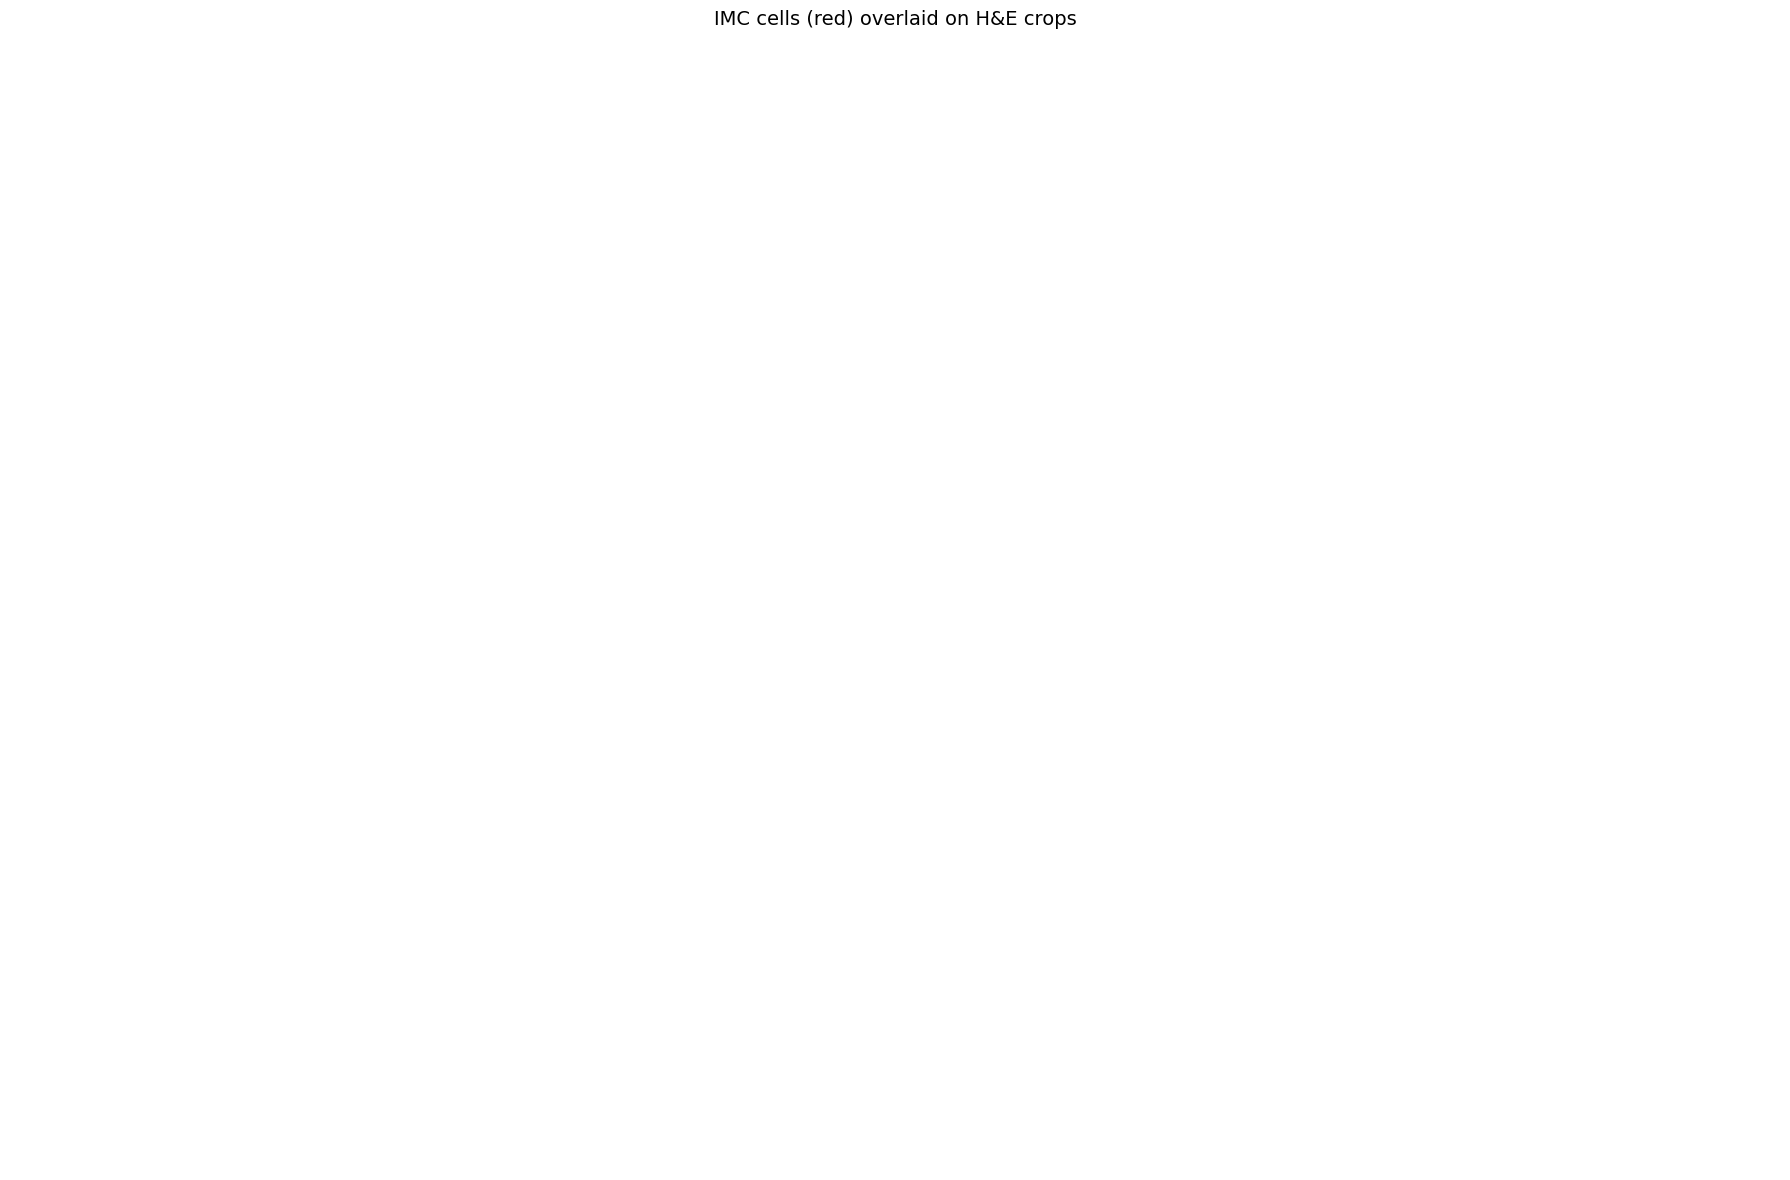

In [13]:
n_show = min(6, len(successful_rois))
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for i in range(n_show):
    roi_name, registrar = successful_rois[i]
    tissue_name = roi_to_tissue_name(roi_name)
    
    # Load H&E crop
    he_crop_path = os.path.join(he_crops_dir, f'he_{tissue_name}.tiff')
    he_crop = tiff.imread(he_crop_path)
    
    # Load AnnData with warped coords
    adata_path = os.path.join(adata_dir, f'adata_{roi_name}.h5ad')
    adata = ad.read_h5ad(adata_path)
    
    axes[i].imshow(he_crop)
    if 'spatial_warped' in adata.obsm:
        axes[i].scatter(
            adata.obsm['spatial_warped'][:, 0],
            adata.obsm['spatial_warped'][:, 1],
            s=0.5, c='red', alpha=0.3
        )
    axes[i].set_title(f'{roi_name} ({adata.n_obs} cells)', fontsize=9)
    axes[i].axis('off')

# Hide unused axes
for j in range(n_show, len(axes)):
    axes[j].axis('off')

plt.suptitle('IMC cells (red) overlaid on H&E crops', fontsize=14)
plt.tight_layout()
plt.show()

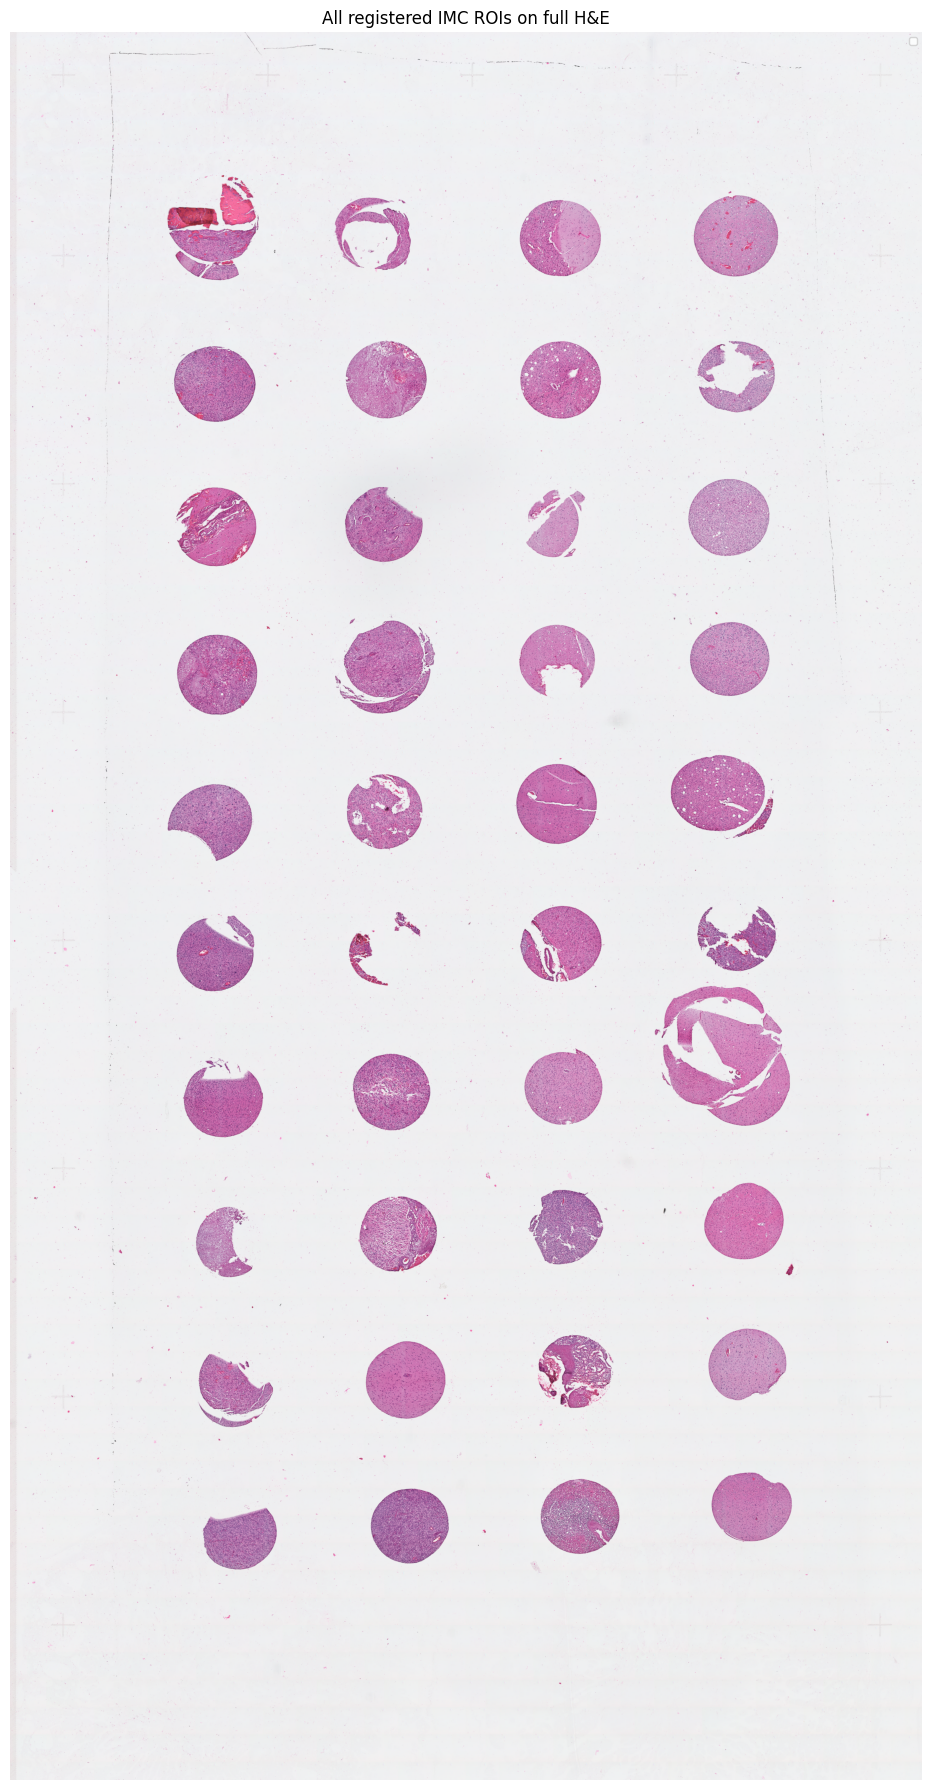

In [14]:
# Overlay ALL registered ROIs on the full H&E
fig, ax = plt.subplots(1, 1, figsize=(12, 18))
ax.imshow(he_img)

colors = plt.cm.tab20(np.linspace(0, 1, len(successful_rois)))

for i, (roi_name, _) in enumerate(successful_rois):
    adata_path = os.path.join(adata_dir, f'adata_{roi_name}.h5ad')
    if not os.path.exists(adata_path):
        continue
    adata = ad.read_h5ad(adata_path)
    if 'spatial_warped_full_he' not in adata.obsm:
        continue
    ax.scatter(
        adata.obsm['spatial_warped_full_he'][:, 0],
        adata.obsm['spatial_warped_full_he'][:, 1],
        s=0.2, c=[colors[i]], alpha=0.5,
        label=roi_to_tissue_name(roi_name)
    )

ax.legend(markerscale=10, fontsize=7, loc='upper right')
ax.set_title('All registered IMC ROIs on full H&E')
ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Summary
print('=== Registration Summary ===')
print(f'Total ROIs attempted: {len(roi_to_ometiff)}')
print(f'Successful: {len(successful_rois)}')
print(f'Failed: {len(failed_rois)}')
print()

for roi_name, _ in successful_rois:
    adata_path = os.path.join(adata_dir, f'adata_{roi_name}.h5ad')
    if os.path.exists(adata_path):
        adata = ad.read_h5ad(adata_path)
        has_warped = 'spatial_warped' in adata.obsm
        print(f'  {roi_name}: {adata.n_obs} cells, warped={has_warped}')